# 01 — Build Daily Feature Dataset

Produces `data/daily_features.csv` — one row per (ticker, trading day) with:
- Market features: open, high, low, close, volume, return_1d, return_3d, rolling_volatility_5d
- Sentiment features: article_count, sentiment_mean, sentiment_max, sentiment_min, sentiment_std, positive_count, negative_count

**No future leakage** — sentiment is aggregated only from articles published on or before each trading day.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

# replacing vader with finBERT llm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# PROJECT_ROOT = Path('..').resolve()
# DATA_DIR = PROJECT_ROOT / 'data'
# FILES_DIR = PROJECT_ROOT / 'files'
# DATA_DIR.mkdir(exist_ok=True)
# sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Base paths
PROJECT_ROOT = Path('..').resolve()
EXTERNAL_ROOT = PROJECT_ROOT
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
os.environ.setdefault('FINBERT_MODEL', str((PROJECT_ROOT / 'models' / 'finbert-tone').resolve()))
os.environ.setdefault('FINBERT_DEVICE', 'cpu')

FILES_DIR = PROJECT_ROOT / 'files'
DATA_DIR = PROJECT_ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True, parents=True)

from dataset_builder import DatasetPaths, build_dataset

print('Project root:', PROJECT_ROOT)
print('External root:', EXTERNAL_ROOT)


Project root: /Users/hamzakhamissa/Desktop/CS4453/Project
External root: /Users/hamzakhamissa/Desktop/CS4453/Project


## 1. Load Market Data

In [2]:
TICKERS = ['NVDA', 'GOOG', 'TSLA']
TICKER_FILE_MAP = {
    'NVDA': FILES_DIR / 'NVDA_q4_2025.csv',
    'GOOG': FILES_DIR / 'GOOG_q4_2025.csv',
    'TSLA': FILES_DIR / 'TSLA_q4_2025.csv',
}

market_frames = []
for ticker, path in TICKER_FILE_MAP.items():
    df = pd.read_csv(path, parse_dates=['Date'])
    df = df.rename(columns={'Date': 'date'})
    df['ticker'] = ticker
    # Keep only raw OHLCV — we'll recompute derived features cleanly
    df = df[['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']]
    market_frames.append(df)

market = pd.concat(market_frames, ignore_index=True)
market = market.sort_values(['ticker', 'date']).reset_index(drop=True)
market['date'] = pd.to_datetime(market['date'])

print('Market data shape:', market.shape)
print('Date range:', market['date'].min().date(), '→', market['date'].max().date())
market.head()

Market data shape: (384, 7)
Date range: 2025-07-01 → 2025-12-31


,date,ticker,open,high,low,close,volume
0,2025-07-01,GOOG,176.804993,177.220001,174.660004,176.910004,25778500
1,2025-07-02,GOOG,176.544998,179.934998,176.089996,179.759995,19325900
2,2025-07-03,GOOG,179.820007,180.770004,178.190002,180.550003,13287400
3,2025-07-07,GOOG,180.134995,180.339996,176.639999,177.559998,20991400
4,2025-07-08,GOOG,178.779999,178.789993,173.919998,175.160004,24108600


## 2. Compute Market Features

In [3]:
def compute_market_features(df):
    df = df.copy().sort_values('date')
    df['return_1d'] = df['close'].pct_change(1)
    df['return_3d'] = df['close'].pct_change(3)
    df['rolling_volatility_5d'] = df['return_1d'].rolling(5).std()
    return df

market = market.groupby('ticker', group_keys=False).apply(compute_market_features)
market = market.reset_index(drop=True)

print('Sample NVDA:')
market[market['ticker'] == 'NVDA'][['date', 'close', 'return_1d', 'return_3d', 'rolling_volatility_5d']].head(8)

Sample NVDA:


,date,close,return_1d,return_3d,rolling_volatility_5d
128,2025-07-01,153.300003,NaN,NaN,NaN
129,2025-07-02,157.250000,0.025766,NaN,NaN
130,2025-07-03,159.339996,0.013291,NaN,NaN
131,2025-07-07,158.240005,-0.006903,0.032224,NaN
132,2025-07-08,160.000000,0.011122,0.017488,NaN
133,2025-07-09,162.880005,0.018000,0.022217,0.012093
134,2025-07-10,164.100006,0.007490,0.037032,0.009465
135,2025-07-11,164.919998,0.004997,0.030750,0.009159


## 3. Load Articles and Score Sentiment (VADER)

VADER is a lexicon-based sentiment analyzer that works well on short financial text.
We score the **headline + summary** (not full_text) — fast, and captures the signal.

In [4]:
articles = pd.read_csv(FILES_DIR / 'q4_articles' / 'raw_articles_q4_2025.csv', parse_dates=['date_utc'])

# Filter to match market data start (Q3 + Q4 2025)
articles = articles[articles['date_utc'] >= '2025-07-01'].copy()
articles['date'] = pd.to_datetime(articles['date_utc']).dt.normalize()

# Normalize ticker (articles use GOOGL, market uses GOOG)
articles['ticker'] = articles['ticker'].replace({'GOOGL': 'GOOG'})

print('Q3+Q4 articles:', len(articles))
print(articles['ticker'].value_counts())
articles[['ticker', 'date', 'headline', 'source_tier']].head()

Q3+Q4 articles: 4827
ticker
NVDA    1660
GOOG    1593
TSLA    1574
Name: count, dtype: int64


,ticker,date,headline,source_tier
0,GOOG,2025-12-30,Meta adds $18 billion in value on report of $2...,high
1,GOOG,2025-12-29,"Alphabet, Nvidia win the AI margin trade as Am...",high
2,GOOG,2025-12-29,Alphabet pulls ahead as the market reprices AI...,high
3,GOOG,2025-12-27,Bitcoin loses a key source of demand as spot E...,high
4,GOOG,2025-12-31,"Dust to data centers: The year AI tech giants,...",high


In [5]:
analyzer = SentimentIntensityAnalyzer()

def score_article(row):
    # Combine headline and summary for richer signal
    headline = str(row['headline']) if pd.notna(row['headline']) else ''
    summary = str(row['summary']) if pd.notna(row['summary']) else ''
    text = f"{headline}. {summary}"
    scores = analyzer.polarity_scores(text)
    return scores['compound']  # -1 (very negative) to +1 (very positive)

tqdm.pandas(desc='Scoring articles')
articles['sentiment_vader'] = articles.progress_apply(score_article, axis=1)

print('\nSentiment distribution:')
print(articles['sentiment_vader'].describe())

# Quick sanity check
articles[['headline', 'sentiment_vader']].sort_values('sentiment_vader').head(3)

Scoring articles:   0%|          | 0/4827 [00:00<?, ?it/s]


Sentiment distribution:
count    4827.000000
mean        0.312290
std         0.455155
min        -0.968200
25%         0.000000
50%         0.381800
75%         0.709250
max         0.988200
Name: sentiment_vader, dtype: float64


,headline,sentiment_vader
2240,S&P 500 Edges Lower But Records Weekly Gain: I...,-0.9682
368,DOJ antitrust head blasts Big Law for obstruct...,-0.9638
3672,Elon Musk Must Face Lawsuit Over Alleged $1 Mi...,-0.9493


In [6]:
articles[['headline', 'sentiment_vader']].sort_values('sentiment_vader', ascending=False).head(3)

,headline,sentiment_vader
1713,"Wall Street closes higher, tech gains continue",0.9882
79,EXCLUSIVE: Jay Woods Picks His Favorite And Le...,0.9864
2064,Exiger Wins AI Company of the Year in STEVIE® ...,0.9858


## 3. Load Articles and Score Sentiment (FinBERT)

In [7]:
articles_finbert = pd.read_csv(FILES_DIR / 'q4_articles' / 'raw_articles_q4_2025.csv', parse_dates=['date_utc'])

# Filter to match market data start (Q3 + Q4 2025)
articles_finbert = articles_finbert[articles_finbert['date_utc'] >= '2025-07-01'].copy()
articles_finbert['date'] = pd.to_datetime(articles_finbert['date_utc']).dt.normalize()

# Normalize ticker (articles use GOOGL, market uses GOOG)
articles_finbert['ticker'] = articles_finbert['ticker'].replace({'GOOGL': 'GOOG'})

print('Q3+Q4 articles:', len(articles_finbert))
print(articles_finbert['ticker'].value_counts())
articles_finbert[['ticker', 'date', 'headline', 'source_tier']].head()

Q3+Q4 articles: 4827
ticker
NVDA    1660
GOOG    1593
TSLA    1574
Name: count, dtype: int64


,ticker,date,headline,source_tier
0,GOOG,2025-12-30,Meta adds $18 billion in value on report of $2...,high
1,GOOG,2025-12-29,"Alphabet, Nvidia win the AI margin trade as Am...",high
2,GOOG,2025-12-29,Alphabet pulls ahead as the market reprices AI...,high
3,GOOG,2025-12-27,Bitcoin loses a key source of demand as spot E...,high
4,GOOG,2025-12-31,"Dust to data centers: The year AI tech giants,...",high


In [8]:
model_name = os.environ['FINBERT_MODEL']
tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    local_files_only=True,
)

device = torch.device(os.environ.get('FINBERT_DEVICE', 'cpu'))
model.to(device)
model.eval()

# map class indices to labels (0 = neutral, 1 = pos, -1 = neg)
labels = model.config.id2label
sent_map = {0: 0, 1: 1, 2: -1}

In [9]:
def score_articles_finbert(df, batch_size=16):
    # Prepare text: Combine headline and summary as you did with VADER
    df['combined_text'] = df['headline'].fillna('') + ". " + df['summary'].fillna('')
    texts = df['combined_text'].tolist()
    all_scores = []

    for i in tqdm(range(0, len(texts), batch_size), desc="FinBERT Scoring"):
        batch_texts = texts[i : i + batch_size]
        
        inputs = tokenizer(
            batch_texts, 
            return_tensors="pt", 
            padding=True, 
            truncation=True, 
            max_length=512
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
            # Map predictions to 1, 0, -1
            scores = [sent_map[p.item()] for p in predictions]
            all_scores.extend(scores)

    return all_scores

# Run the scoring
articles_finbert['sentiment_score'] = score_articles_finbert(articles_finbert)

FinBERT Scoring:   0%|          | 0/302 [00:00<?, ?it/s]

## 4. Aggregate Sentiment to Daily Level

In [10]:
def aggregate_daily_sentiment(df, sentiment_col='sentiment_vader'):
    if sentiment_col not in df.columns:
        raise ValueError(f'Missing {sentiment_col}. Available columns: {df.columns.tolist()}')

    agg = df.groupby(['ticker', 'date'])[sentiment_col].agg(
        article_count='count',
        sentiment_mean='mean',
        sentiment_max='max',
        sentiment_min='min',
        sentiment_std='std',
    ).reset_index()
    
    # Positive/negative counts
    pos = df[df[sentiment_col] > 0.05].groupby(['ticker', 'date']).size().reset_index(name='positive_count')
    neg = df[df[sentiment_col] < -0.05].groupby(['ticker', 'date']).size().reset_index(name='negative_count')
    
    agg = agg.merge(pos, on=['ticker', 'date'], how='left')
    agg = agg.merge(neg, on=['ticker', 'date'], how='left')
    agg[['positive_count', 'negative_count']] = agg[['positive_count', 'negative_count']].fillna(0).astype(int)
    agg['sentiment_std'] = agg['sentiment_std'].fillna(0)
    
    return agg

daily_sentiment_vader = aggregate_daily_sentiment(articles)

print('Daily sentiment rows:', len(daily_sentiment_vader))
daily_sentiment_vader.head()

Daily sentiment rows: 144


,ticker,date,article_count,sentiment_mean,sentiment_max,sentiment_min,sentiment_std,positive_count,negative_count
0,GOOG,2025-07-23,1,0.542300,0.5423,0.5423,0.000000,1,0
1,GOOG,2025-07-24,1,0.659700,0.6597,0.6597,0.000000,1,0
2,GOOG,2025-07-25,63,0.297068,0.9705,-0.9267,0.462961,39,13
3,GOOG,2025-07-26,10,0.475480,0.8957,0.0000,0.333022,8,0
4,GOOG,2025-07-27,23,0.430887,0.8834,-0.5550,0.416520,17,3


### LLM version

In [11]:
def aggregate_daily_sentiment_finbert(df):
    agg = df.groupby(['ticker', 'date'])['sentiment_score'].agg(
        article_count='count',
        sentiment_mean='mean',
        sentiment_max='max',
        sentiment_min='min',
        sentiment_std='std',
    ).reset_index()
    
    # Positive/negative counts
    pos = df[df['sentiment_score'] == 1].groupby(['ticker', 'date']).size().reset_index(name='positive_count')
    neg = df[df['sentiment_score'] == -1].groupby(['ticker', 'date']).size().reset_index(name='negative_count')
    
    agg = agg.merge(pos, on=['ticker', 'date'], how='left')
    agg = agg.merge(neg, on=['ticker', 'date'], how='left')
    
    agg[['positive_count', 'negative_count']] = agg[['positive_count', 'negative_count']].fillna(0).astype(int)
    agg['sentiment_std'] = agg['sentiment_std'].fillna(0)
    
    # Net sentiment
    agg['net_sentiment_score'] = (agg['positive_count'] - agg['negative_count']) / agg['article_count']
    
    return agg

daily_sentiment_finbert = aggregate_daily_sentiment_finbert(articles_finbert)

In [12]:
daily_sentiment_finbert.head()

,ticker,date,article_count,sentiment_mean,sentiment_max,sentiment_min,sentiment_std,positive_count,negative_count,net_sentiment_score
0,GOOG,2025-07-23,1,1.000000,1,1,0.000000,1,0,1.000000
1,GOOG,2025-07-24,1,0.000000,0,0,0.000000,0,0,0.000000
2,GOOG,2025-07-25,63,0.349206,1,-1,0.765353,33,11,0.349206
3,GOOG,2025-07-26,10,0.300000,1,-1,0.674949,4,1,0.300000
4,GOOG,2025-07-27,23,0.391304,1,-1,0.656376,11,2,0.391304


## 5. Merge Market + Sentiment

In [13]:
daily = market.merge(daily_sentiment_vader, on=['ticker', 'date'], how='left')

# Fill sentiment columns with 0 on days with no articles
sentiment_cols = ['article_count', 'sentiment_mean', 'sentiment_max', 'sentiment_min',
                  'sentiment_std', 'positive_count', 'negative_count']
daily[sentiment_cols] = daily[sentiment_cols].fillna(0)

daily = daily.sort_values(['ticker', 'date']).reset_index(drop=True)

print('Final dataset shape:', daily.shape)
print('Columns:', list(daily.columns))
daily.head()

Final dataset shape: (384, 17)
Columns: ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'return_1d', 'return_3d', 'rolling_volatility_5d', 'article_count', 'sentiment_mean', 'sentiment_max', 'sentiment_min', 'sentiment_std', 'positive_count', 'negative_count']


,date,ticker,open,high,low,close,volume,return_1d,return_3d,rolling_volatility_5d,article_count,sentiment_mean,sentiment_max,sentiment_min,sentiment_std,positive_count,negative_count
0,2025-07-01,GOOG,176.804993,177.220001,174.660004,176.910004,25778500,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-07-02,GOOG,176.544998,179.934998,176.089996,179.759995,19325900,0.016110,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-07-03,GOOG,179.820007,180.770004,178.190002,180.550003,13287400,0.004395,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-07-07,GOOG,180.134995,180.339996,176.639999,177.559998,20991400,-0.016561,0.003674,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-07-08,GOOG,178.779999,178.789993,173.919998,175.160004,24108600,-0.013517,-0.025590,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Quality Check

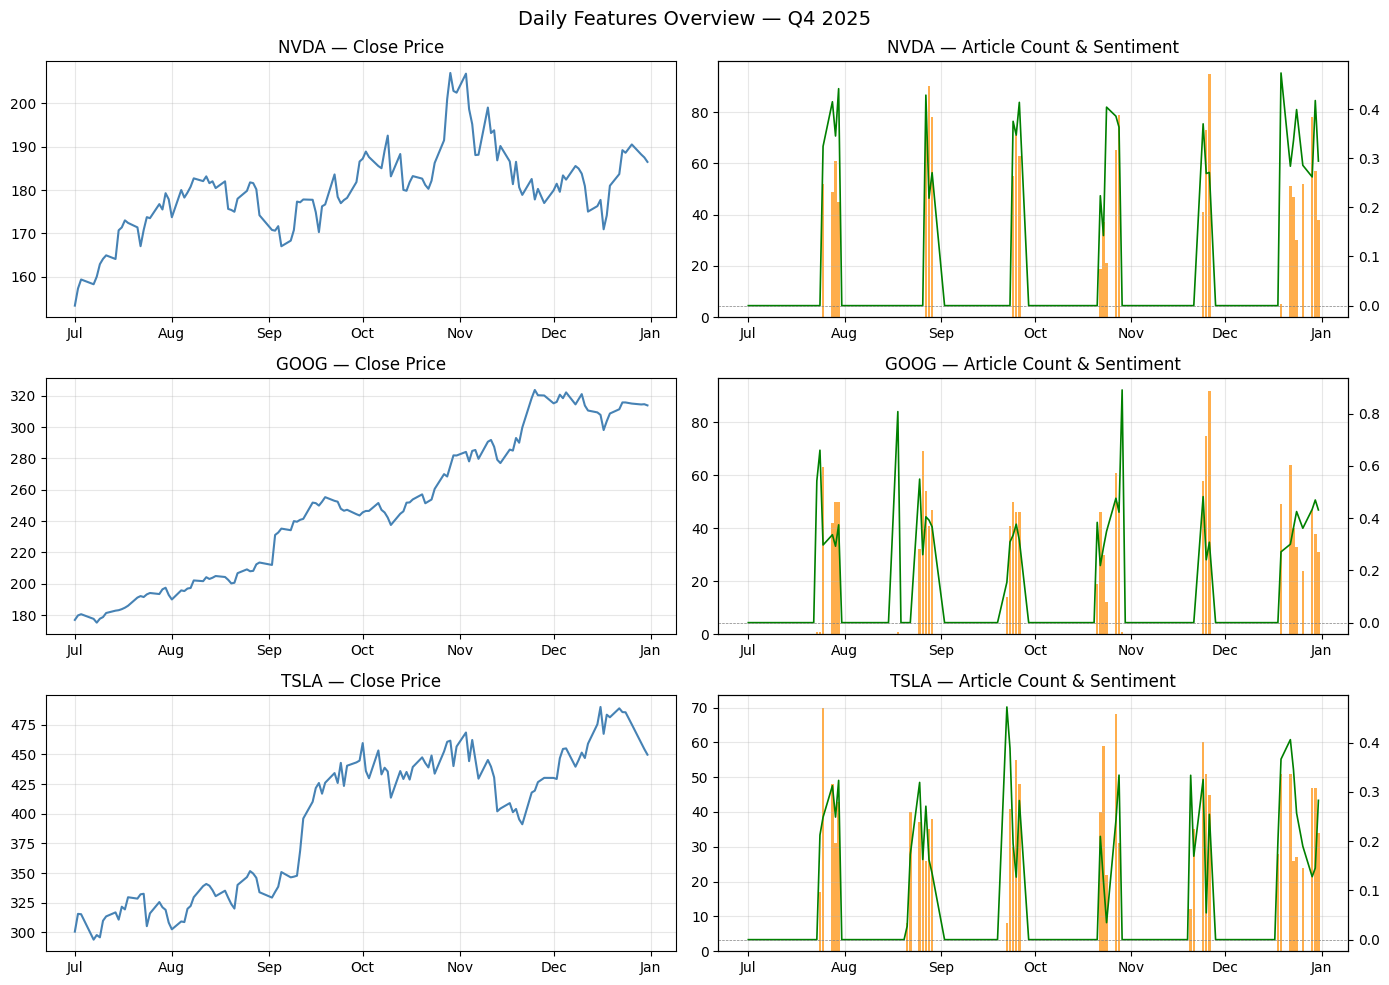

Saved plot to data/dataset_overview.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Daily Features Overview — Q4 2025', fontsize=14)

for i, ticker in enumerate(TICKERS):
    t = daily[daily['ticker'] == ticker]
    
    ax1 = axes[i, 0]
    ax1.plot(t['date'], t['close'], label='close', color='steelblue')
    ax1.set_title(f'{ticker} — Close Price')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax1.grid(alpha=0.3)
    
    ax2 = axes[i, 1]
    ax2.bar(t['date'], t['article_count'], color='darkorange', alpha=0.7, label='articles')
    ax2_twin = ax2.twinx()
    ax2_twin.plot(t['date'], t['sentiment_mean'], color='green', linewidth=1.2, label='sentiment mean')
    ax2_twin.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax2.set_title(f'{ticker} — Article Count & Sentiment')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot to data/dataset_overview.png')

In [15]:
# Check for missing values
print('Missing values:')
print(daily.isnull().sum())
print()
print('Rows per ticker:')
print(daily['ticker'].value_counts().sort_index())
print()
print('Days with 0 articles per ticker:')
print(daily.groupby('ticker')['article_count'].apply(lambda x: (x == 0).sum()))

Missing values:
date                      0
ticker                    0
open                      0
high                      0
low                       0
close                     0
volume                    0
return_1d                 3
return_3d                 9
rolling_volatility_5d    15
article_count             0
sentiment_mean            0
sentiment_max             0
sentiment_min             0
sentiment_std             0
positive_count            0
negative_count            0
dtype: int64

Rows per ticker:
ticker
GOOG    128
NVDA    128
TSLA    128
Name: count, dtype: int64

Days with 0 articles per ticker:
ticker
GOOG     93
NVDA    102
TSLA     92
Name: article_count, dtype: int64


## 7. Save Dataset

In [16]:
# Rebuild the final dataset using the reusable session-aware pipeline
ticker_file_map = {
    'NVDA': FILES_DIR / 'NVDA_q4_2025.csv',
    'GOOG': FILES_DIR / 'GOOG_q4_2025.csv',
    'TSLA': FILES_DIR / 'TSLA_q4_2025.csv',
}
paths = DatasetPaths(
    market_dir=FILES_DIR,
    articles_csv=FILES_DIR / 'q4_articles' / 'raw_articles_q4_2025.csv',
    output_daily=DATA_DIR / 'daily_features.csv',
    output_article_sentiments=DATA_DIR / 'article_sentiments.csv',
)

daily, article_sentiments = build_dataset(paths, ticker_file_map)
daily.to_csv(paths.output_daily, index=False)
print(f'Saved {len(daily)} rows to {paths.output_daily}')
print()
print('Column descriptions:')
col_descriptions = {
    'date': 'Trading date',
    'ticker': 'Stock ticker (NVDA, GOOG, TSLA)',
    'return_1d': '1-day close-to-close return',
    'return_3d': '3-day close-to-close return',
    'rolling_volatility_5d': '5-day rolling std of daily returns',
    'article_count': 'Articles aligned to the trading session',
    'sentiment_mean': 'Mean VADER compound score across aligned articles',
    'sentiment_abs_mean': 'Average absolute sentiment magnitude',
    'sentiment_range': 'Daily max minus min sentiment',
    'sentiment_balance': 'Net positive-vs-negative article balance',
    'sentiment_mean_lag_1d': 'Prior-session mean sentiment',
    'sentiment_mean_lag_3d': '3-session lagged mean sentiment',
    'premarket_article_count': 'Articles published before 9:30 ET',
    'intraday_article_count': 'Articles published between 9:30 and 16:00 ET',
    'after_hours_article_count': 'Articles published after 16:00 ET and shifted forward',
}
for col, desc in col_descriptions.items():
    print(f'  {col:<28} {desc}')


Saved 384 rows to /Users/hamzakhamissa/Desktop/CS4453/Project/data/daily_features.csv

Column descriptions:
  date                         Trading date
  ticker                       Stock ticker (NVDA, GOOG, TSLA)
  return_1d                    1-day close-to-close return
  return_3d                    3-day close-to-close return
  rolling_volatility_5d        5-day rolling std of daily returns
  article_count                Articles aligned to the trading session
  sentiment_mean               Mean VADER compound score across aligned articles
  sentiment_abs_mean           Average absolute sentiment magnitude
  sentiment_range              Daily max minus min sentiment
  sentiment_balance            Net positive-vs-negative article balance
  sentiment_mean_lag_1d        Prior-session mean sentiment
  sentiment_mean_lag_3d        3-session lagged mean sentiment
  premarket_article_count      Articles published before 9:30 ET
  intraday_article_count       Articles published between 9:

In [17]:
article_sentiments.to_csv(paths.output_article_sentiments, index=False)
print('Saved article-level sentiments to data/article_sentiments.csv')
article_sentiments.head()


Saved article-level sentiments to data/article_sentiments.csv


,article_id,ticker,headline,source_tier,quality_score,published_at_utc,published_at_et,news_session,aligned_trading_date,sentiment_vader
0,eb366b07d9d3f23cfad0cf4a,GOOG,Meta adds $18 billion in value on report of $2...,high,7,2025-12-30 19:12:40+00:00,2025-12-30 14:12:40-05:00,intraday,2025-12-30,0.8271
1,aaa3458eb67d83a4189aa3e8,GOOG,"Alphabet, Nvidia win the AI margin trade as Am...",high,7,2025-12-29 15:56:44+00:00,2025-12-29 10:56:44-05:00,intraday,2025-12-29,0.8555
2,a4e9aed0077fc6bd8115c296,GOOG,Alphabet pulls ahead as the market reprices AI...,high,7,2025-12-29 09:42:13+00:00,2025-12-29 04:42:13-05:00,premarket,2025-12-29,0.6369
3,78986de88e2022b347a99abb,GOOG,Bitcoin loses a key source of demand as spot E...,high,7,2025-12-27 03:41:05+00:00,2025-12-26 22:41:05-05:00,after_hours,2025-12-29,-0.8658
5,0cb7e60f113fe7702090436b,GOOG,Google wraps up best year on Wall Street since...,high,5,2025-12-31 16:06:31+00:00,2025-12-31 11:06:31-05:00,intraday,2025-12-31,0.8720


## 8. Build FinBERT Dataset

Scores the same articles with FinBERT using the local model directory on CPU.
Saves to `data/daily_features_finbert.csv` — used to train the FinBERT sentiment agents.
Column schema is identical to the VADER dataset so the same `TradingEnv` works for both.

In [18]:
from dataset_builder import build_dataset, DatasetPaths

finbert_paths = DatasetPaths(
    market_dir=FILES_DIR,
    articles_csv=FILES_DIR / 'q4_articles' / 'raw_articles_q4_2025.csv',
    output_daily=DATA_DIR / 'daily_features_finbert.csv',
    output_article_sentiments=DATA_DIR / 'article_sentiments_finbert.csv',
)

ticker_file_map_main = {
    'NVDA': FILES_DIR / 'NVDA_q4_2025.csv',
    'GOOG': FILES_DIR / 'GOOG_q4_2025.csv',
    'TSLA': FILES_DIR / 'TSLA_q4_2025.csv',
}

print('Scoring articles with FinBERT...')
daily_finbert, article_sentiments_finbert = build_dataset(
    finbert_paths, ticker_file_map_main, scorer='finbert'
)

daily_finbert.to_csv(finbert_paths.output_daily, index=False)
article_sentiments_finbert.to_csv(finbert_paths.output_article_sentiments, index=False)

print(f'Saved {len(daily_finbert)} rows to {finbert_paths.output_daily}')
print('Columns:', list(daily_finbert.columns))
daily_finbert.head()

Scoring articles with FinBERT...
Saved 384 rows to /Users/hamzakhamissa/Desktop/CS4453/Project/data/daily_features_finbert.csv
Columns: ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'return_1d', 'return_3d', 'rolling_volatility_5d', 'article_count', 'sentiment_mean', 'sentiment_max', 'sentiment_min', 'sentiment_std', 'sentiment_abs_mean', 'sentiment_range', 'positive_count', 'negative_count', 'net_sentiment_count', 'sentiment_balance', 'after_hours_article_count', 'intraday_article_count', 'premarket_article_count', 'after_hours_sentiment_mean', 'intraday_sentiment_mean', 'premarket_sentiment_mean', 'article_count_change_1d', 'sentiment_mean_change_1d', 'sentiment_mean_lag_1d', 'sentiment_mean_lag_3d', 'sentiment_abs_mean_lag_1d', 'sentiment_std_lag_1d']


,date,ticker,open,high,low,close,volume,return_1d,return_3d,rolling_volatility_5d,...,premarket_article_count,after_hours_sentiment_mean,intraday_sentiment_mean,premarket_sentiment_mean,article_count_change_1d,sentiment_mean_change_1d,sentiment_mean_lag_1d,sentiment_mean_lag_3d,sentiment_abs_mean_lag_1d,sentiment_std_lag_1d
0,2025-07-01,GOOG,176.804993,177.220001,174.660004,176.910004,25778500,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-07-02,GOOG,176.544998,179.934998,176.089996,179.759995,19325900,0.016110,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-07-03,GOOG,179.820007,180.770004,178.190002,180.550003,13287400,0.004395,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-07-07,GOOG,180.134995,180.339996,176.639999,177.559998,20991400,-0.016561,0.003674,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-07-08,GOOG,178.779999,178.789993,173.919998,175.160004,24108600,-0.013517,-0.025590,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
